# NGC 4151 continuum-background estimation with DC4 mock data

This notebook estimates the background underneath NGC 4151 in the DC4 mock data. The input histogram has already been cut to times when NGC 4151 is within 60 degrees of the field of view and is not Earth-occulted. **Do not apply that cut to the histogram again.** Instead, the same cut is reconstructed from the full DC4 orientation history and used to generate the NGC 4151 point-source response (PSR).

The mock data contain instrumental background and 64 astrophysical sources. With only NGC 4151 masked, the output is an **effective background**: instrumental background plus all sources other than NGC 4151. A later spectral fit should therefore model NGC 4151 alone unless additional modeled sources are also removed or masked when constructing the background template.

Two estimates are produced:

1. A data-only interpolation estimate, useful as a blind baseline.
2. A supervised GCN estimate using the known mock truth (total data minus the injected NGC 4151 component). This is a validation benchmark, not a data-only estimate.

## Environment

The neural-network section requires COSIPY's optional ML dependencies. From the repository root, install them with `python -m pip install -e '.[ML]'`, restart the kernel, and confirm that `cosipy.with_ml` is `True`.

In [15]:
from pathlib import Path
import logging
import warnings

import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import numpy as np
from histpy import Histogram

import cosipy
from cosipy.background_estimation import ContinuumEstimationInterp
from cosipy.data_io import EmCDSBinnedData
from cosipy.event_selection import GoodTimeInterval
from cosipy.response import (
    BinnedInstrumentResponse,
    DetectorResponse,
    PointSourceResponse,
)
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.spacecraftfile import SpacecraftHistory

logging.basicConfig(level=logging.INFO)
%matplotlib inline

print(f"COSIPY ML dependencies available: {cosipy.with_ml}")

COSIPY ML dependencies available: True


## Inputs and run configuration

All count histograms below represent the native three-month simulation. Exposure multiplication for a later 24-month closure test should be done only after background estimation, and should be applied consistently to the data, estimated background, and spacecraft livetime.

In [16]:
notebook_dir = Path(
    "/Users/parshadkp/Software/cosipy/docs/tutorials/"
    "background_estimation/continuum_estimation"
)
dc4_root = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    "COSI/Radio_Quiet_AGN/DC4_Files"
)

input_data_file = (
    dc4_root
    / "Mock_Data/Mock_Data_Cut/"
    / "mock_with_updated_NGC4151_FluxNTH_0p30_time_cut.hdf5"
)
ngc4151_component_file = (
    dc4_root
    / "DC4_Sources/DC4_Mod/"
    / "NGC_4151_ec200_0p30_DC4_COSI_cpl_pl_time_cut_in_fov.hdf5"
)
instrumental_background_file = (
    dc4_root
    / "Background/"
    / (
        "Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_"
        "NGC4151_60deg_fov_cut.hdf5"
    )
)
orientation_file = (
    dc4_root / "DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori"
)
response_file = (
    dc4_root
    / (
        "ResponseContinuum.o3.e100_10000.b10log.s10396905069491."
        "m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"
    )
)

output_dir = notebook_dir / "ngc4151_background_outputs"
output_dir.mkdir(parents=True, exist_ok=True)
psr_file = output_dir / "ngc4151_dc4_60deg_fov_cut_psr.h5"
effective_truth_file = output_dir / "dc4_effective_bg_without_ngc4151.h5"

source_coord = SkyCoord(
    l=155.077404 * u.deg,
    b=75.06317 * u.deg,
    frame="galactic",
)
max_offaxis = 60 * u.deg
earth_occ = True
containment = 0.6
em_bin = 2
phi_bin = 4

REBUILD_PSR = False
RUN_NN = True
NN_EPOCHS = 200  # Use 1-5 first for a quick smoke test.
RUN_BACKGROUND_ONLY_GCN = True
BACKGROUND_ONLY_NN_EPOCHS = 200
RUN_SPECTRAL_FIT = True
SPECTRAL_BACKGROUND_METHOD = "effective_gcn"  # interpolation/effective_gcn/exact_truth
RANDOM_SEED = 4151

required_files = [
    input_data_file,
    ngc4151_component_file,
    instrumental_background_file,
    orientation_file,
    response_file,
]
for path in required_files:
    if not path.exists():
        raise FileNotFoundError(path)

## Load and validate the count histograms

The estimator works on `Em`, `Phi`, and `PsiChi`. The instrumental-background file retains a `Time` axis, so it is projected before comparing its measurement axes with the already-projected mock data.

In [17]:
measurement_axes = ["Em", "Phi", "PsiChi"]

mock_hist = Histogram.open(input_data_file).project(measurement_axes)
ngc4151_hist = Histogram.open(ngc4151_component_file).project(measurement_axes)
instrumental_background_full = Histogram.open(instrumental_background_file)
instrumental_background = instrumental_background_full.project(measurement_axes)

if mock_hist.axes != ngc4151_hist.axes:
    raise ValueError("The NGC 4151 component axes do not match the mock data.")
if mock_hist.axes != instrumental_background.axes:
    raise ValueError("The FOV-cut instrumental-background axes do not match the mock data.")

expected_shape = (10, 30, 768)
if mock_hist.axes.shape != expected_shape:
    raise ValueError(
        f"Expected Em x Phi x PsiChi shape {expected_shape}; got {mock_hist.axes.shape}."
    )

psichi_axis = mock_hist.axes["PsiChi"]
if psichi_axis.nside != 8 or str(psichi_axis.scheme).lower() != "ring":
    raise ValueError(
        f"Expected Galactic RING NSIDE=8; got {psichi_axis.coordsys}, "
        f"{psichi_axis.scheme}, NSIDE={psichi_axis.nside}."
    )

print("Measurement shape:", mock_hist.axes.shape)
print("PsiChi:", psichi_axis.coordsys, psichi_axis.scheme, psichi_axis.nside)
print("Mock counts:", mock_hist.project("Em").to_dense(copy=False).contents.sum())

Measurement shape: (10, 30, 768)
PsiChi: <Galactic Frame> RING 8
Mock counts: 26185378.398761287


## Reconstruct the time cut for the PSR

The mock histogram has already been time-cut, but its PSR must be integrated over the same selected pointing history. We therefore reproduce the 60-degree pointing and Earth-occultation selection from the full DC4 orientation file. The resulting history is used only for response generation.

In [18]:
sc_orientation_full = SpacecraftHistory.open(orientation_file)
source_gti = GoodTimeInterval.from_pointing_cut(
    source_coord,
    sc_orientation_full,
    max_offaxis,
)
sc_orientation_cut = sc_orientation_full.apply_gti(source_gti)

full_livetime = sc_orientation_full.cumulative_livetime().to_value(u.s)
cut_livetime = sc_orientation_cut.cumulative_livetime().to_value(u.s)
print(f"Full orientation livetime: {full_livetime:,.1f} s")
print(f"NGC 4151 FOV-cut livetime: {cut_livetime:,.1f} s")
print(f"Selected livetime fraction: {cut_livetime / full_livetime:.4f}")

if "Time" in instrumental_background_full.axes.labels:
    print(
        "Instrumental-background time bins (projected out for estimation):",
        instrumental_background_full.axes["Time"].nbins,
    )

# The histogram Time bins and the 15-second orientation intervals are different
# discretizations and therefore should not be compared one-for-one.

Full orientation livetime: 6,579,555.0 s
NGC 4151 FOV-cut livetime: 980,415.0 s
Selected livetime fraction: 0.1490
Instrumental-background time bins (projected out for estimation): 2195


## Generate the NGC 4151 point-source response

The scattering map uses NSIDE 16, twice the data's `PsiChi` NSIDE, matching the binned spectral-analysis setup. The output retains the incident-energy axis `Ei`; the background estimator later projects the PSR to `Em`, `Phi`, and `PsiChi` when constructing the containment mask.

In [19]:
data = EmCDSBinnedData(mock_hist)
scatt_nside = 2 * data.axes["PsiChi"].nside

if REBUILD_PSR or not psr_file.exists():
    scatt_map = sc_orientation_cut.get_scatt_map(
        nside=scatt_nside,
        target_coord=source_coord,
        earth_occ=earth_occ,
    )

    with FullDetectorResponse.open(response_file) as detector_response:
        instrument_response = BinnedInstrumentResponse(detector_response, data)
        ngc4151_psr = PointSourceResponse.from_scatt_map(
            source_coord,
            data,
            instrument_response,
            scatt_map,
            energy_axis=detector_response.axes["Ei"],
            polarization_axis=(
                detector_response.axes["Pol"]
                if "Pol" in detector_response.axes.labels
                else None
            ),
        )
        ngc4151_psr.write(psr_file, overwrite=True)
    print("Wrote PSR:", psr_file)
else:
    print("Using existing PSR:", psr_file)

Using existing PSR: /Users/parshadkp/Software/cosipy/docs/tutorials/background_estimation/continuum_estimation/ngc4151_background_outputs/ngc4151_dc4_60deg_fov_cut_psr.h5


In [20]:
psr_hist = DetectorResponse.open(psr_file)
psr_projected = psr_hist.project(measurement_axes).to_dense(copy=False)
if psr_projected.axes != mock_hist.axes:
    raise ValueError("The projected PSR axes do not match the mock data.")

psr_map = np.asarray(psr_projected.contents.value)
psr_normalization = psr_map.sum(axis=-1)
if not np.all(np.isfinite(psr_normalization)) or np.any(psr_normalization < 0):
    raise ValueError("At least one Em/Phi PSR slice has an invalid normalization.")
zero_response_slices = psr_normalization == 0
if np.all(zero_response_slices):
    raise ValueError("The PSR is zero in every Em/Phi slice.")

# Kinematically inaccessible Em/Phi combinations can have zero response.
# The estimator leaves these slices completely unmasked; suppress the harmless
# zero-division warning raised while it normalizes them.
with np.errstate(divide="ignore", invalid="ignore"):
    mask_map = ContinuumEstimationInterp.mask_from_cumdist_vectorized(
        psr_map, containment=containment
    )
if np.any(mask_map[zero_response_slices] != 1):
    raise ValueError("A zero-response Em/Phi slice was unexpectedly masked.")
masked_fraction = np.mean(mask_map == 0, axis=-1)
print("Projected PSR shape:", psr_map.shape)
print("Zero-response Em/Phi slices:", np.count_nonzero(zero_response_slices))
print(
    f"Masked pixel fraction at containment={containment}: "
    f"{masked_fraction.min():.3f} to {masked_fraction.max():.3f}"
)

Projected PSR shape: (10, 30, 768)
Zero-response Em/Phi slices: 12
Masked pixel fraction at containment=0.6: 0.000 to 0.525


## Construct the mock effective-background truth

For this controlled DC4 study, subtract the matching injected NGC 4151 count histogram from the total mock histogram. The result contains the instrumental background and every other simulated source. It is used to evaluate interpolation and to supervise the GCN. In real data this truth histogram would not be available.

In [21]:
mock_map = np.asarray(mock_hist.to_dense(copy=False).contents, dtype=float)
ngc4151_map = np.asarray(ngc4151_hist.to_dense(copy=False).contents, dtype=float)
effective_truth_map = mock_map - ngc4151_map

minimum_truth_count = effective_truth_map.min()
if minimum_truth_count < -1e-9:
    raise ValueError(
        "Subtracting the NGC 4151 component produced negative bins "
        f"(minimum {minimum_truth_count}). Confirm that the component exactly "
        "matches the one inserted into this mock file."
    )
effective_truth_map = np.clip(effective_truth_map, 0, None)
effective_truth = Histogram(
    mock_hist.axes,
    contents=effective_truth_map,
    sparse=True,
)
effective_truth.write(effective_truth_file, overwrite=True)
print("Wrote mock effective-background truth:", effective_truth_file)
print("NGC 4151 component counts:", ngc4151_map.sum())
print("Effective-background counts:", effective_truth_map.sum())

Wrote mock effective-background truth: /Users/parshadkp/Software/cosipy/docs/tutorials/background_estimation/continuum_estimation/ngc4151_background_outputs/dc4_effective_bg_without_ngc4151.h5
NGC 4151 component counts: 76103.39876128685
Effective-background counts: 26109275.0


## Blind interpolation baseline

This estimate uses only the total mock data and the NGC 4151 PSR. The known truth is not passed to the estimator. Unmasked bins—including counts from the other 63 sources—are preserved.

INFO:cosipy.background_estimation.ContinuumEstimationInterp:...loading the pre-computed point source response ...
INFO:cosipy.background_estimation.ContinuumEstimationInterp:--> done
INFO:cosipy.background_estimation.ContinuumEstimationInterp:Inpainted histogram saved to /Users/parshadkp/Software/cosipy/docs/tutorials/background_estimation/continuum_estimation/ngc4151_background_outputs/ngc4151_interp_c0.6_estimated_bg.h5


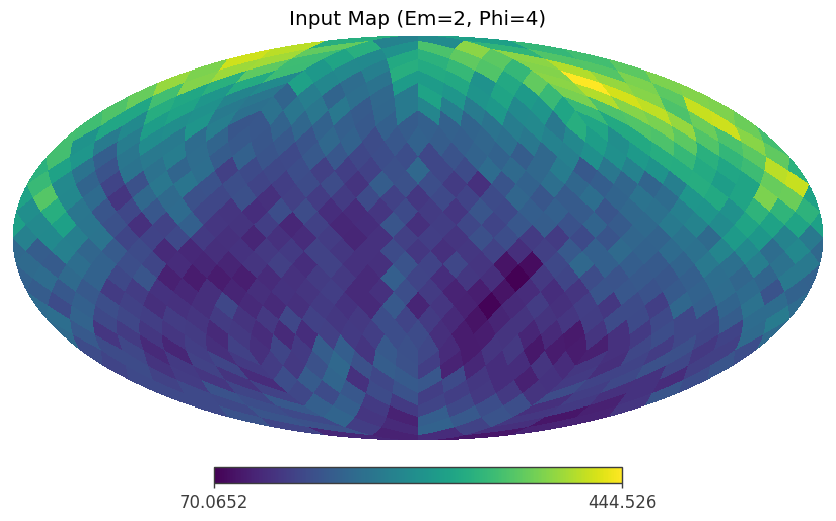

INFO:cosipy.background_estimation.ContinuumEstimationInterp:Saved visualization: /Users/parshadkp/Software/cosipy/docs/tutorials/background_estimation/continuum_estimation/ngc4151_background_outputs/ngc4151_interp_c0.6_true_E2_Phi4.pdf


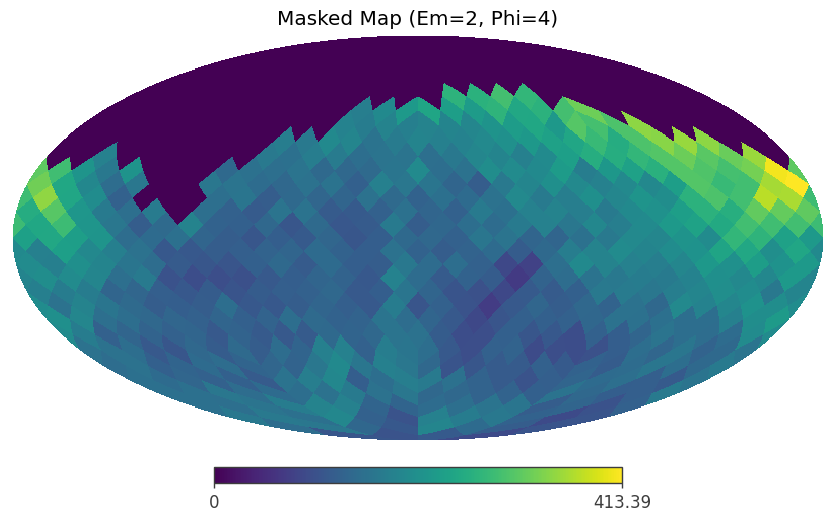

INFO:cosipy.background_estimation.ContinuumEstimationInterp:Saved visualization: /Users/parshadkp/Software/cosipy/docs/tutorials/background_estimation/continuum_estimation/ngc4151_background_outputs/ngc4151_interp_c0.6_masked_E2_Phi4.pdf


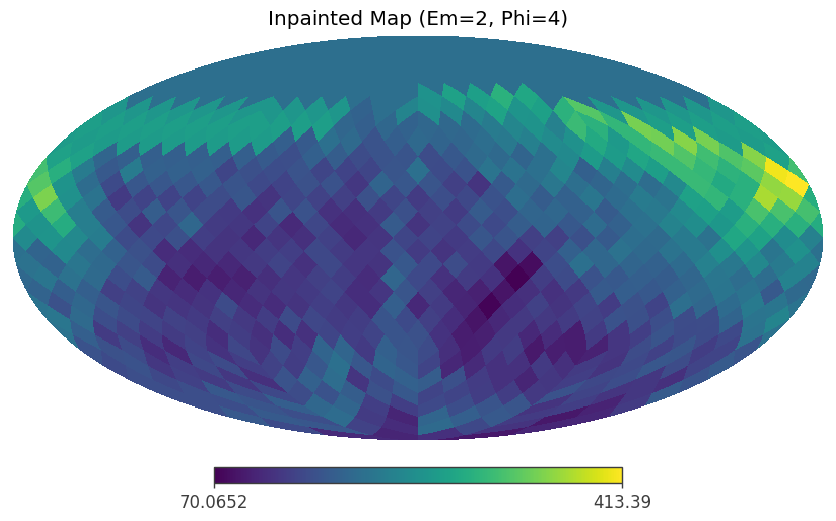

INFO:cosipy.background_estimation.ContinuumEstimationInterp:Saved visualization: /Users/parshadkp/Software/cosipy/docs/tutorials/background_estimation/continuum_estimation/ngc4151_background_outputs/ngc4151_interp_c0.6_inpainted_E2_Phi4.pdf
INFO:cosipy.background_estimation.ContinuumEstimationInterp:Total time elapsed: 1.11 seconds


Interpolation estimate: /Users/parshadkp/Software/cosipy/docs/tutorials/background_estimation/continuum_estimation/ngc4151_background_outputs/ngc4151_interp_c0.6_estimated_bg.h5


In [22]:
interp_prefix = output_dir / f"ngc4151_interp_c{containment:.1f}"
interp_estimator = ContinuumEstimationInterp()
with np.errstate(divide="ignore", invalid="ignore"):
    interp_estimator.estimate_bg(
        input_data=str(input_data_file),
        psr_file=str(psr_file),
        containment=containment,
        prefix=str(interp_prefix),
        visualize=True,
        em_bin=em_bin,
        phi_bin=phi_bin,
        evaluate=False,
        show_plots=True,
        verbose=False,
    )
interp_file = Path(f"{interp_prefix}_estimated_bg.h5")
print("Interpolation estimate:", interp_file)

## Supervised GCN benchmark

This mock-only benchmark supplies the exact effective-background truth in the masked region. Begin with `NN_EPOCHS = 1` to verify the workflow before a longer run.

The current self-supervised implementation selects random loss pixels but does not remove them from the network input. Until that target-leakage issue is corrected and tested, this notebook does not present a self-supervised result as a science-ready estimate.

INFO:cosipy.background_estimation.ContinuumEstimationInterp:...loading the pre-computed point source response ...
INFO:cosipy.background_estimation.ContinuumEstimationInterp:--> done
INFO:cosipy.background_estimation.ml.ContinuumEstimationNN:Using GCN model.


Inpainting (Em, Phi):   0%|          | 0/300 [00:00<?, ?map/s]

INFO:cosipy.background_estimation.ContinuumEstimationInterp:Inpainted histogram saved to /Users/parshadkp/Software/cosipy/docs/tutorials/background_estimation/continuum_estimation/ngc4151_background_outputs/ngc4151_gcn_supervised_e200_c0.6_estimated_bg.h5


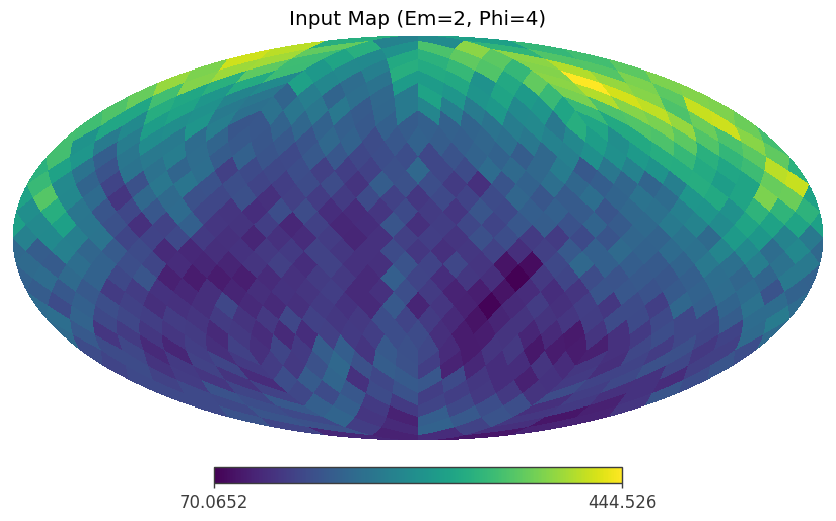

INFO:cosipy.background_estimation.ContinuumEstimationInterp:Saved visualization: /Users/parshadkp/Software/cosipy/docs/tutorials/background_estimation/continuum_estimation/ngc4151_background_outputs/ngc4151_gcn_supervised_e200_c0.6_true_E2_Phi4.pdf


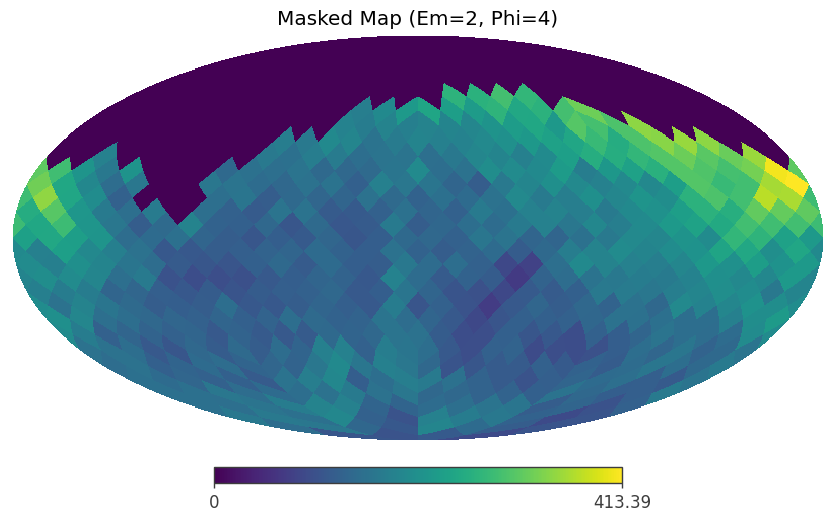

INFO:cosipy.background_estimation.ContinuumEstimationInterp:Saved visualization: /Users/parshadkp/Software/cosipy/docs/tutorials/background_estimation/continuum_estimation/ngc4151_background_outputs/ngc4151_gcn_supervised_e200_c0.6_masked_E2_Phi4.pdf


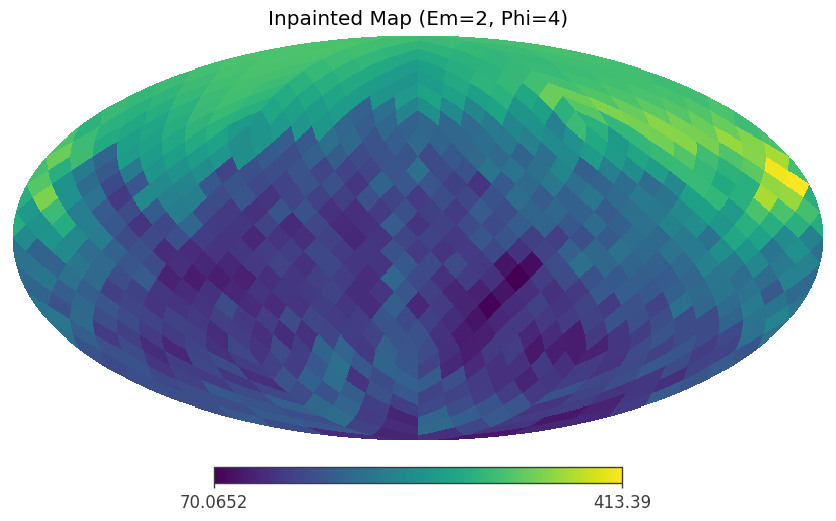

INFO:cosipy.background_estimation.ContinuumEstimationInterp:Saved visualization: /Users/parshadkp/Software/cosipy/docs/tutorials/background_estimation/continuum_estimation/ngc4151_background_outputs/ngc4151_gcn_supervised_e200_c0.6_inpainted_E2_Phi4.pdf
INFO:cosipy.background_estimation.ml.ContinuumEstimationNN:Total time elapsed: 690.25 seconds


Supervised GCN estimate: /Users/parshadkp/Software/cosipy/docs/tutorials/background_estimation/continuum_estimation/ngc4151_background_outputs/ngc4151_gcn_supervised_e200_c0.6_estimated_bg.h5


In [23]:
nn_file = None
if RUN_NN:
    if not cosipy.with_ml:
        raise ImportError(
            "Install COSIPY with python -m pip install -e '.[ML]' and restart the kernel."
        )

    from cosipy.background_estimation.ml import ContinuumEstimationNN

    np.random.seed(RANDOM_SEED)
    try:
        import torch
        torch.manual_seed(RANDOM_SEED)
    except ImportError:
        pass

    nn_prefix = output_dir / (
        f"ngc4151_gcn_supervised_e{NN_EPOCHS}_c{containment:.1f}"
    )
    nn_estimator = ContinuumEstimationNN()
    with np.errstate(divide="ignore", invalid="ignore"):
        nn_estimator.estimate_bg(
            input_data=str(input_data_file),
            psr_file=str(psr_file),
            background_model=str(effective_truth_file),
            training_mode="supervised",
            containment=containment,
            epochs=NN_EPOCHS,
            model_type="gcn",
            nn_model="new",
            nn_model_savename=str(nn_prefix),
            lr=1e-3,
            prefix=str(nn_prefix),
            visualize=True,
            em_bin=em_bin,
            phi_bin=phi_bin,
            evaluate=False,
            show_plots=True,
            verbose=False,
        )
    nn_file = Path(f"{nn_prefix}_estimated_bg.h5")
    print("Supervised GCN estimate:", nn_file)

## GCN trained on pure instrumental background

This control experiment uses the FOV-cut instrumental-background histogram as both the masked network input and the supervised target. It tests how well the GCN reconstructs the instrumental background alone, without any of the 64 astrophysical sources. The NGC 4151 PSR is used only to define the region hidden from the network.

This output is **not** the correct standalone background for an NGC 4151-only fit of the full mock data, because it does not contain the other 63 sources. The later spectral-fit section therefore uses an effective-background template.

INFO:cosipy.background_estimation.ContinuumEstimationInterp:...loading the pre-computed point source response ...
INFO:cosipy.background_estimation.ContinuumEstimationInterp:--> done
INFO:cosipy.background_estimation.ml.ContinuumEstimationNN:Using GCN model.


Inpainting (Em, Phi):   0%|          | 0/300 [00:00<?, ?map/s]

INFO:cosipy.background_estimation.ContinuumEstimationInterp:Inpainted histogram saved to /Users/parshadkp/Software/cosipy/docs/tutorials/background_estimation/continuum_estimation/ngc4151_background_outputs/ngc4151_gcn_instrumental_bg_e200_c0.6_estimated_bg.h5


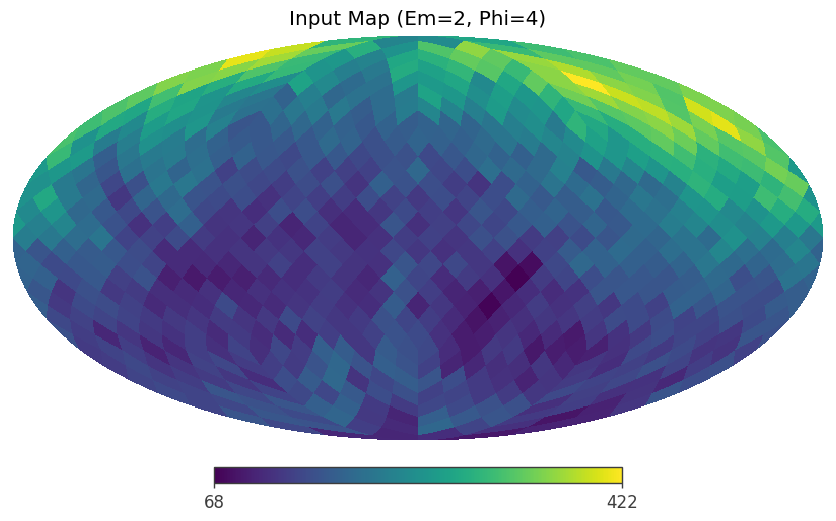

INFO:cosipy.background_estimation.ContinuumEstimationInterp:Saved visualization: /Users/parshadkp/Software/cosipy/docs/tutorials/background_estimation/continuum_estimation/ngc4151_background_outputs/ngc4151_gcn_instrumental_bg_e200_c0.6_true_E2_Phi4.pdf


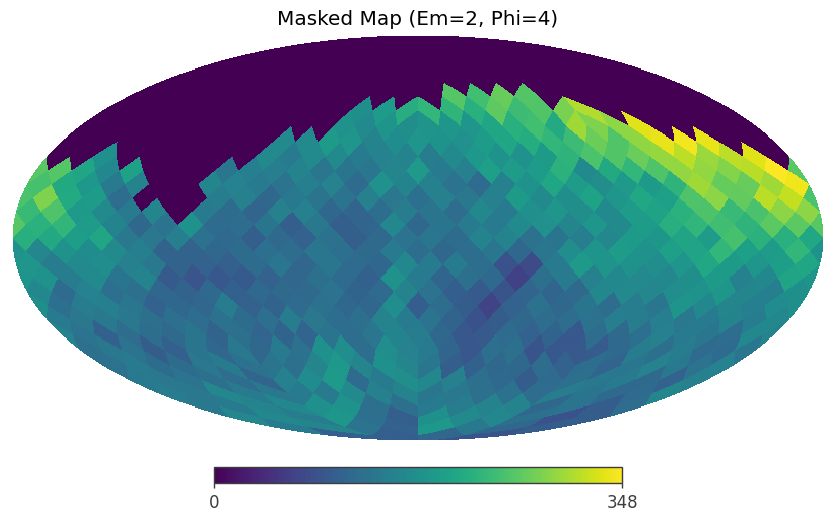

INFO:cosipy.background_estimation.ContinuumEstimationInterp:Saved visualization: /Users/parshadkp/Software/cosipy/docs/tutorials/background_estimation/continuum_estimation/ngc4151_background_outputs/ngc4151_gcn_instrumental_bg_e200_c0.6_masked_E2_Phi4.pdf


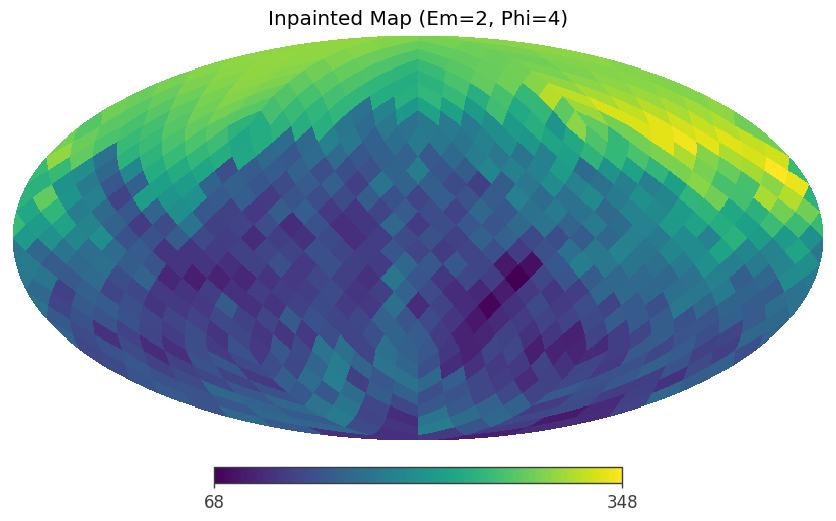

INFO:cosipy.background_estimation.ContinuumEstimationInterp:Saved visualization: /Users/parshadkp/Software/cosipy/docs/tutorials/background_estimation/continuum_estimation/ngc4151_background_outputs/ngc4151_gcn_instrumental_bg_e200_c0.6_inpainted_E2_Phi4.pdf
INFO:cosipy.background_estimation.ml.ContinuumEstimationNN:Total time elapsed: 692.67 seconds


Pure-background GCN estimate: /Users/parshadkp/Software/cosipy/docs/tutorials/background_estimation/continuum_estimation/ngc4151_background_outputs/ngc4151_gcn_instrumental_bg_e200_c0.6_estimated_bg.h5


In [24]:
background_only_nn_file = None
if RUN_BACKGROUND_ONLY_GCN:
    if not cosipy.with_ml:
        raise ImportError(
            "Install COSIPY with python -m pip install -e '.[ML]' and restart the kernel."
        )

    from cosipy.background_estimation.ml import ContinuumEstimationNN

    np.random.seed(RANDOM_SEED)
    try:
        import torch
        torch.manual_seed(RANDOM_SEED)
    except ImportError:
        pass

    background_only_prefix = output_dir / (
        f"ngc4151_gcn_instrumental_bg_e{BACKGROUND_ONLY_NN_EPOCHS}_"
        f"c{containment:.1f}"
    )
    background_only_estimator = ContinuumEstimationNN()
    with np.errstate(divide="ignore", invalid="ignore"):
        background_only_estimator.estimate_bg(
            input_data=str(instrumental_background_file),
            psr_file=str(psr_file),
            background_model=str(instrumental_background_file),
            training_mode="supervised",
            containment=containment,
            epochs=BACKGROUND_ONLY_NN_EPOCHS,
            model_type="gcn",
            nn_model="new",
            nn_model_savename=str(background_only_prefix),
            lr=1e-3,
            prefix=str(background_only_prefix),
            visualize=True,
            em_bin=em_bin,
            phi_bin=phi_bin,
            evaluate=False,
            show_plots=True,
            verbose=False,
        )
    background_only_nn_file = Path(
        f"{background_only_prefix}_estimated_bg.h5"
    )
    print("Pure-background GCN estimate:", background_only_nn_file)

## Mask-focused diagnostics

A whole-histogram comparison is dominated by unmasked bins, which both methods copy from the input. The metrics below therefore evaluate only the bins replaced by inpainting and also verify that unmasked bins were preserved exactly.


WARNING UserWarning: Supervised GCN contains negative predicted background bins.



Interpolation:
  masked-bin fractional L1 error: 0.19782
  masked-bin RMSE: 58.09413 counts
  minimum estimated bin: 0.00000
  maximum unmasked-bin change: 0
Supervised GCN:
  masked-bin fractional L1 error: 0.11472
  masked-bin RMSE: 32.50786 counts
  minimum estimated bin: -0.45115
  maximum unmasked-bin change: 0


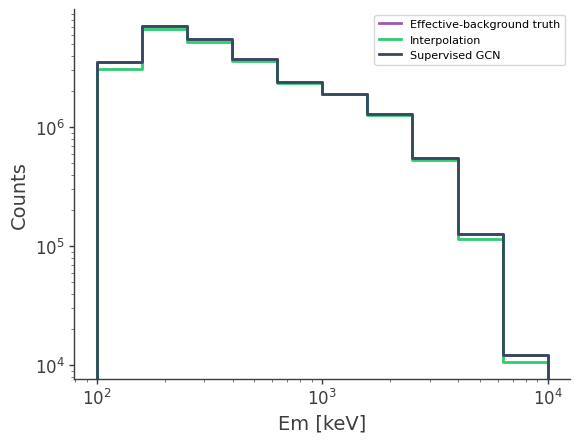

Pure instrumental-background GCN:
  masked-bin fractional L1 error: 0.11517
  masked-bin RMSE: 31.18702 counts
  minimum estimated bin: -0.38185
  negative predicted bins: 317
  maximum unmasked-bin change: 0
  median loss, epoch 1 -> final: 50.31601 -> 20.95917



WARNING UserWarning: Pure-background GCN contains negative predicted bins.



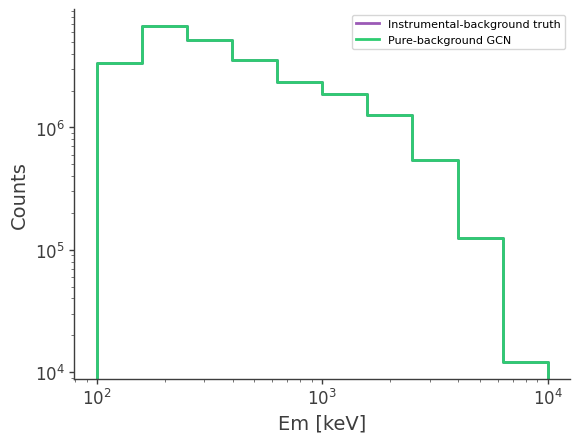

In [25]:
def load_map(path):
    hist = Histogram.open(path).project(measurement_axes).to_dense(copy=False)
    return hist, np.asarray(hist.contents, dtype=float)


def report_masked_metrics(label, path):
    hist, estimate_map = load_map(path)
    if hist.axes != mock_hist.axes:
        raise ValueError(f"{label} axes do not match the mock data.")

    masked = mask_map == 0
    unmasked = ~masked
    residual = estimate_map - effective_truth_map
    truth_scale = effective_truth_map[masked].sum()
    fractional_l1 = (
        np.abs(residual[masked]).sum() / truth_scale
        if truth_scale > 0
        else np.nan
    )
    rmse = np.sqrt(np.mean(residual[masked] ** 2))
    max_unmasked_change = np.max(np.abs(estimate_map[unmasked] - mock_map[unmasked]))

    print(f"{label}:")
    print(f"  masked-bin fractional L1 error: {fractional_l1:.5f}")
    print(f"  masked-bin RMSE: {rmse:.5f} counts")
    print(f"  minimum estimated bin: {estimate_map.min():.5f}")
    print(f"  maximum unmasked-bin change: {max_unmasked_change:.5g}")

    if not np.all(np.isfinite(estimate_map)):
        raise ValueError(f"{label} contains NaN or infinite bins.")
    if estimate_map.min() < 0:
        warnings.warn(f"{label} contains negative predicted background bins.")
    if max_unmasked_change != 0:
        warnings.warn(f"{label} changed bins outside the NGC 4151 mask.")

    return hist, estimate_map


interp_hist, interp_map = report_masked_metrics("Interpolation", interp_file)
estimates = [("Effective-background truth", effective_truth)]
estimates.append(("Interpolation", interp_hist))
if nn_file is not None:
    nn_hist, nn_map = report_masked_metrics("Supervised GCN", nn_file)
    estimates.append(("Supervised GCN", nn_hist))

first_label, first_hist = estimates[0]
ax, _ = first_hist.project("Em").draw(label=first_label)
for label, hist in estimates[1:]:
    hist.project("Em").draw(ax=ax, label=label)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel("Counts")
ax.legend()
plt.show()

if background_only_nn_file is not None:
    background_only_hist, background_only_map = load_map(background_only_nn_file)
    instrumental_background_map = np.asarray(
        instrumental_background.to_dense(copy=False).contents,
        dtype=float,
    )
    masked = mask_map == 0
    unmasked = ~masked
    residual = background_only_map - instrumental_background_map
    truth_scale = instrumental_background_map[masked].sum()
    fractional_l1 = np.abs(residual[masked]).sum() / truth_scale
    rmse = np.sqrt(np.mean(residual[masked] ** 2))
    max_unmasked_change = np.max(
        np.abs(background_only_map[unmasked] - instrumental_background_map[unmasked])
    )

    print("Pure instrumental-background GCN:")
    print(f"  masked-bin fractional L1 error: {fractional_l1:.5f}")
    print(f"  masked-bin RMSE: {rmse:.5f} counts")
    print(f"  minimum estimated bin: {background_only_map.min():.5f}")
    print(f"  negative predicted bins: {np.count_nonzero(background_only_map < 0)}")
    print(f"  maximum unmasked-bin change: {max_unmasked_change:.5g}")
    background_only_loss = np.load(
        f"{background_only_prefix}_training_loss.npy"
    )
    print(
        "  median loss, epoch 1 -> final: "
        f"{np.median(background_only_loss[..., 0]):.5f} -> "
        f"{np.median(background_only_loss[..., -1]):.5f}"
    )

    if background_only_map.min() < 0:
        warnings.warn("Pure-background GCN contains negative predicted bins.")

    ax, _ = instrumental_background.project("Em").draw(
        label="Instrumental-background truth"
    )
    background_only_hist.project("Em").draw(
        ax=ax, label="Pure-background GCN"
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylabel("Counts")
    ax.legend()
    plt.show()

## NGC 4151 spectral fit using the estimated effective background

The fit below uses the native three-month mock data and models NGC 4151 with a cutoff power law only. Its index is fixed at -1.75, while its normalization and cutoff energy are fitted. The dotted injected curve retains the cutoff-plus-tail spectrum actually used to make the mock, so it also shows the effect of fitting that mock with the simpler model.

By default, the fit uses the supervised effective-background GCN estimate, which contains the instrumental background and the other 63 sources. Use `SPECTRAL_BACKGROUND_METHOD = "interpolation"` for the blind estimate, or `"exact_truth"` for a simulation-only closure test.

The pure-instrumental-background GCN output is intentionally not offered as an NGC 4151-only fit background: it omits the other 63 sources present in the data. Using it would require explicitly modeling those sources.

Because only 60% of the NGC 4151 PSR is masked, some target tails remain in an estimated effective-background template. The code explicitly warns when a fit lands on a parameter boundary; such a result diagnoses background-template bias and should not be reported as an NGC 4151 measurement. The `exact_truth` option is not an estimator and must be used only to verify closure on this mock data.

In [26]:
from astromodels import Cutoff_powerlaw, Parameter, Powerlaw
from threeML import DataList, JointLikelihood, Model, PointSource

from cosipy.background_estimation import FreeNormBinnedBackground
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.response import (
    BinnedInstrumentResponse,
    BinnedThreeMLModelFolding,
    BinnedThreeMLPointSourceResponse,
)
from cosipy.statistics import PoissonLikelihood

In [27]:
spectral_background_options = {
    "interpolation": interp_file,
    "exact_truth": effective_truth_file,
}
if nn_file is not None:
    spectral_background_options["effective_gcn"] = nn_file
if SPECTRAL_BACKGROUND_METHOD not in spectral_background_options:
    raise ValueError(
        f"Unknown or unavailable spectral background: {SPECTRAL_BACKGROUND_METHOD}. "
        f"Choose from {list(spectral_background_options)}."
    )

spectral_background_file = spectral_background_options[SPECTRAL_BACKGROUND_METHOD]
spectral_background_loaded = Histogram.open(spectral_background_file).project(
    measurement_axes
)
spectral_background_map = np.asarray(
    spectral_background_loaded.to_dense(copy=False).contents, dtype=float
)
if spectral_background_map.min() < 0:
    warnings.warn(
        "Clipping negative estimated-background bins to zero for the Poisson fit."
    )
spectral_background_map = np.clip(spectral_background_map, 0, None)
spectral_background_map += np.finfo(float).tiny
spectral_background = Histogram(
    mock_hist.axes, contents=spectral_background_map, sparse=True
)

spectral_data = EmCDSBinnedData(mock_hist)
spectral_detector_response = FullDetectorResponse.open(str(response_file))
spectral_instrument_response = BinnedInstrumentResponse(
    spectral_detector_response, spectral_data
)
spectral_psr = BinnedThreeMLPointSourceResponse(
    data=spectral_data,
    instrument_response=spectral_instrument_response,
    sc_history=sc_orientation_cut,
    energy_axis=spectral_detector_response.axes["Ei"],
    polarization_axis=(
        spectral_detector_response.axes["Pol"]
        if "Pol" in spectral_detector_response.axes.labels
        else None
    ),
    nside=2 * spectral_data.axes["PsiChi"].nside,
)
spectral_response = BinnedThreeMLModelFolding(
    data=spectral_data, point_source_response=spectral_psr
)
spectral_bkg_dist = {"effective_background": spectral_background}
spectral_bkg = FreeNormBinnedBackground(
    spectral_bkg_dist, sc_history=sc_orientation_cut, copy=False
)
spectral_like_fun = PoissonLikelihood(
    spectral_data, spectral_response, spectral_bkg
)
spectral_cosi = ThreeMLPluginInterface(
    "cosi", spectral_like_fun, spectral_response, spectral_bkg
)

initial_background_rate = spectral_background_map.sum() / cut_livetime
spectral_cosi.bkg_parameter["effective_background"] = Parameter(
    "effective_background",
    initial_background_rate,
    min_value=0.0,
    max_value=max(100.0, 3 * initial_background_rate),
    delta=0.05,
    unit=u.Hz,
)
print("Spectral-fit background:", spectral_background_file)
print(f"Initial background rate: {initial_background_rate:.3f} Hz")

Spectral-fit background: /Users/parshadkp/Software/cosipy/docs/tutorials/background_estimation/continuum_estimation/ngc4151_background_outputs/ngc4151_gcn_supervised_e200_c0.6_estimated_bg.h5
Initial background rate: 26.657 Hz



WARNING UserWarning: Clipping negative estimated-background bins to zero for the Poisson fit.



In [34]:
D = 0.30

# Injected spectrum used only for closure comparison.
spectrum_inj_cpl = Cutoff_powerlaw()
spectrum_inj_cpl.K.value = 0.15
spectrum_inj_cpl.piv.value = 1.0
spectrum_inj_cpl.xc.value = 200.0
spectrum_inj_cpl.index.value = -1.75
spectrum_inj_cpl.K.unit = 1 / (u.cm**2 * u.s * u.keV)
spectrum_inj_cpl.piv.unit = u.keV
spectrum_inj_cpl.xc.unit = u.keV

spectrum_inj_tail = Powerlaw()
spectrum_inj_tail.K.value = D * spectrum_inj_cpl.evaluate_at(200.0)
spectrum_inj_tail.piv.value = 200.0
spectrum_inj_tail.index.value = -3.8
spectrum_inj_tail.K.unit = 1 / (u.cm**2 * u.s * u.keV)
spectrum_inj_tail.piv.unit = u.keV
spectrum_inj = spectrum_inj_cpl + spectrum_inj_tail

# NGC 4151-only fit model: cutoff power law.
fit_spectrum = Cutoff_powerlaw()
fit_spectrum.K.value = 1.410226e-5
fit_spectrum.K.min_value = 1e-8
fit_spectrum.K.max_value = 1e-2
fit_spectrum.K.unit = 1 / (u.cm**2 * u.s * u.keV)
fit_spectrum.K.fix = False
fit_spectrum.piv.value = 200.0
fit_spectrum.piv.unit = u.keV
fit_spectrum.piv.fix = True
fit_spectrum.index.value = -1.75
fit_spectrum.index.fix = False
fit_spectrum.xc.value = 200.0
fit_spectrum.xc.min_value = 100.0
fit_spectrum.xc.max_value = 10000.0
fit_spectrum.xc.unit = u.keV
fit_spectrum.xc.fix = False

ngc4151_source = PointSource(
    "ngc4151",
    l=source_coord.galactic.l.to_value(u.deg),
    b=source_coord.galactic.b.to_value(u.deg),
    spectral_shape=fit_spectrum,
)
spectral_model = Model(ngc4151_source)
print("Free spectral parameters:", list(spectral_model.free_parameters))

Free spectral parameters: ['ngc4151.spectrum.main.Cutoff_powerlaw.K', 'ngc4151.spectrum.main.Cutoff_powerlaw.index', 'ngc4151.spectrum.main.Cutoff_powerlaw.xc']


In [36]:
spectral_like = None
if RUN_SPECTRAL_FIT:
    spectral_plugins = DataList(spectral_cosi)
    spectral_like = JointLikelihood(
        spectral_model, spectral_plugins, verbose=False
    )
    _ = spectral_like.fit()

11:55:08 WARNING   External parameter effective_background already exist in the model. Overwriting     ]8;id=705280;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/model.py\model.py]8;;\:]8;id=151602;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/model.py#593\593]8;;\
                  it...                                                                                            

11:55:08 INFO      set the minimizer to minuit                                             ]8;id=120562;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=223865;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

11:55:14 ERROR     Last status:                                                             ]8;id=496561;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py\minuit_minimizer.py]8;;\:]8;id=94486;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py#161\161]8;;\

         ERROR     ┌─────────────────────────────────────────────────────────────────────── ]8;id=468273;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py\minuit_minimizer.py]8;;\:]8;id=364629;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py#164\164]8;;\
                  ──┐                                                                                              

         ERROR     │                                Migrad                                  ]8;id=824425;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py\minuit_minimizer.py]8;;\:]8;id=82450;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py#164\164]8;;\
                  │                                                                                                

...

         ERROR     │ 1 │ ngc4151_spectrum_main_Cutoff_powerlaw_index │   -1.75   │   0.00   ]8;id=314537;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py\minuit_minimizer.py]8;;\:]8;id=21019;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py#169\169]8;;\
                  │            │            │   -10   │   10    │       │                                          

         ERROR     │ 2 │ ngc4151_spectrum_main_Cutoff_powerlaw_xc    │   2.301   │   0.000  ]8;id=543385;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py\minuit_minimizer.py]8;;\:]8;id=558599;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py#169\169]8;;\
                  │            │            │    2    │    4    │       │                                          

         ERROR     │ 3 │ effective_background                        │ 2.6501e1  │ 0.0000e1 ]8;id=25609;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py\minuit_minimizer.py]8;;\:]8;id=234526;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py#169\169]8;;\
                  │            │            │    0    │   100   │       │                                          

         ERROR     └───┴─────────────────────────────────────────────┴───────────┴───────── ]8;id=137552;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py\minuit_minimizer.py]8;;\:]8;id=48662;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minuit_minimizer.py#169\169]8;;\
                  ──┴────────────┴────────────┴─────────┴─────────┴───────┘                                        

FitFailed: MIGRAD call failed. This is usually due to unconstrained parameters.

Best fit values:

,result,unit
parameter,,
ngc4151.spectrum.main.composite.K_1,(5.67 -0.31 +0.32) x 10^-6,1 / (keV s cm2)
ngc4151.spectrum.main.composite.xc_1,(10.0000 +/- 0.0010) x 10^3,keV
ngc4151.spectrum.main.composite.K_2,(6.35 -0.19 +0.20) x 10^-6,1 / (keV s cm2)
ngc4151.spectrum.main.composite.index_2,-5.0000 +/- 0.0004,
effective_background,(2.6501 +/- 0.0008) x 10,Hz


Correlation matrix:

1.00,0.01,-0.26,-0.01,-0.66
0.01,1.00,-0.01,0.00,0.00
-0.26,-0.01,1.00,0.02,-0.18
-0.01,0.00,0.02,1.00,0.00
-0.66,0.00,-0.18,0.00,1.00


Values of -log(likelihood) at the minimum:

...

         WARNING   The current value of the parameter xc_1 (10.0) was below the new minimum 100.0. ]8;id=314929;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=622424;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

         WARNING   The current value of the parameter K_2 (1.0) was above the new maximum 0.01.    ]8;id=145301;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=849609;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter K_1 (1.0) was above the new maximum 0.01.    ]8;id=554420;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=57484;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc_1 (10.0) was below the new minimum 100.0. ]8;id=136224;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=504918;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

         WARNING   The current value of the parameter K_2 (1.0) was above the new maximum 0.01.    ]8;id=8829;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=195309;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

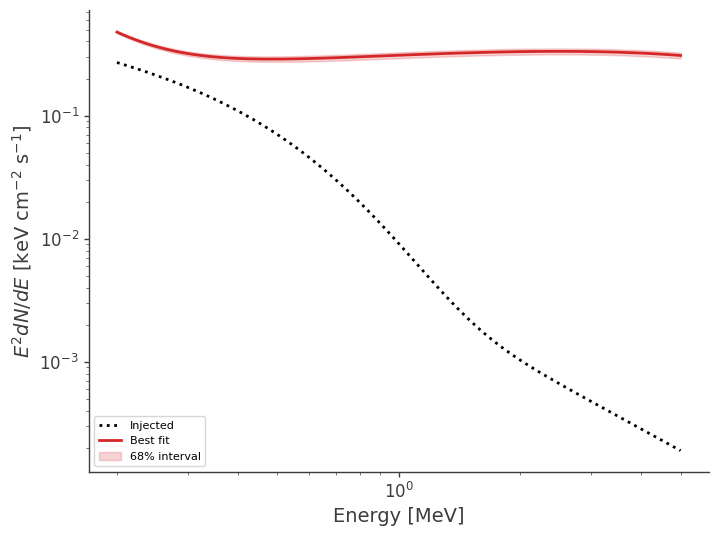

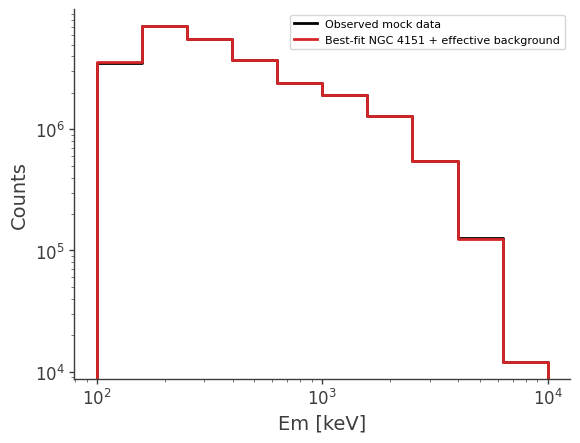

In [30]:
if spectral_like is not None:
    spectral_results = spectral_like.results
    spectral_results.display()

    boundary_hits = []
    for path, parameter in spectral_results.optimized_model.free_parameters.items():
        span = parameter.max_value - parameter.min_value
        if span <= 0:
            continue
        distance = min(
            parameter.value - parameter.min_value,
            parameter.max_value - parameter.value,
        )
        if distance / span < 1e-3:
            boundary_hits.append(path)
    if boundary_hits:
        warnings.warn(
            "Spectral fit reached parameter boundaries: "
            + ", ".join(boundary_hits)
            + ". Treat this as evidence of background-template bias, not a "
            + "valid NGC 4151 spectrum."
        )

    fit_parameters = {
        parameter.name: spectral_results.get_variates(parameter.path)
        for parameter in spectral_results.optimized_model["ngc4151"].parameters.values()
        if parameter.free
    }
    fitted_flux = spectral_results.propagate(
        spectral_results.optimized_model["ngc4151"].spectrum.main.shape.evaluate_at,
        **fit_parameters,
    )

    energy = np.geomspace(200, 5000, 100)
    flux_median = np.zeros_like(energy)
    flux_lo = np.zeros_like(energy)
    flux_hi = np.zeros_like(energy)
    flux_injected = np.zeros_like(energy)
    for i, energy_value in enumerate(energy):
        flux_variates = fitted_flux(energy_value)
        flux_median[i] = flux_variates.median
        flux_lo[i], flux_hi[i] = flux_variates.equal_tail_interval(cl=0.68)
        flux_injected[i] = spectrum_inj.evaluate_at(energy_value)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(energy / 1000, energy**2 * flux_injected, "k:", label="Injected")
    ax.plot(energy / 1000, energy**2 * flux_median, color="tab:red", label="Best fit")
    ax.fill_between(
        energy / 1000,
        energy**2 * flux_lo,
        energy**2 * flux_hi,
        color="tab:red",
        alpha=0.2,
        label="68% interval",
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Energy [MeV]")
    ax.set_ylabel(r"$E^2 dN/dE$ [keV cm$^{-2}$ s$^{-1}$]")
    ax.legend()
    plt.show()

    source_expectation = spectral_response.expectation(copy=True)
    background_expectation = spectral_bkg.expectation(copy=True)
    total_expectation = source_expectation + background_expectation
    ax, _ = spectral_data.data.project("Em").draw(
        label="Observed mock data", color="black"
    )
    total_expectation.project("Em").draw(
        ax=ax, label="Best-fit NGC 4151 + effective background", color="tab:red"
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylabel("Counts")
    ax.legend()
    plt.show()